# Part B: From Understanding to Grouping

Now that we have simplified the data using dimensionality reduction,  
we move to the next natural question:

> **Can we automatically group similar data points together?**

This leads us to: **Clustering**


## Clustering: Letting Data Form Its Own Groups

Clustering is about:

- Finding natural groupings in data  
- Without using any labels  

Instead of being told what belongs where, the model discovers patterns on its own. It learns:
- Which points are similar  
- Which points are different  



## K-Means: A Simple Clustering Algorithm

One of the most widely used clustering algorithms is: **K-Means**. K-Means divides the dataset into **K clusters**. Each cluster has a center called a **centroid**

<!--
## Objective of K-Means

:contentReference[oaicite:0]{index=0}

This means:

Minimize the total distance between data points and their assigned cluster centers.

In simple terms:
- Points should be close to their centroid  
- Clusters should be compact  
 -->


$$\min \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Where:
- K = number of clusters  
- $C_i$ = set of points in cluster \(i\)  
- $mu_i$ = centroid (mean) of cluster \(i\)  
- $||x - \mu_i\|^2$ = squared distance between a point and its centroid  

K-Means tries to **minimize the total squared distance** between data points and their assigned cluster centers. This quantity is also known as:**Inertia** or **WCSS (Within-Cluster Sum of Squares)**.

<p align="center">
  <img src="https://miro.medium.com/v2/resize:fit:1400/1*zlZOSJB_DISgUxb06QwISw.png" width="500"/>
</p>

<p align="center">
<b>Figure:</b> Illustration of K-Means objective showing compact clusters (low intra-cluster distance) and well-separated clusters (high inter-cluster distance).Source: Medium
</p>


> **WCSS** is the sum of squared distances from each point to its assigned centroid.

- It measures how compact the clusters are  
- Lower value → better clustering  


## Intra-cluster vs Inter-cluster

### (a) Intra-cluster Distance (Within Cluster)
- Distance between points and their centroid  
- Should be **small**  
- Measures how compact each cluster is  

K-Means **minimizes this**


### (b) Inter-cluster Distance (Between Clusters)
- Distance between different cluster centroids  
- Should be **large**  
- Ensures clusters are well separated  

K-Means does not explicitly maximize this,  
but minimizing intra-cluster distance indirectly improves separation.

---

Remeber:
Good clustering means:
- Points within a cluster are **close together** (low intra-cluster distance)  
- Different clusters are **far apart** (high inter-cluster separation)  
---

## How K-Means Works (Step-by-Step)

<p align="center">
  <img src="https://www.simplilearn.com/ice9/free_resources_article_thumb/slide32.JPG" width="500"/>
</p>

<p align="center">
<b>Figure:</b> K-Means clustering process showing iterative steps: initializing centroids, assigning points to nearest centroid, and updating centroids until convergence.  Source: Simplilear</b>

Think of it like this:

1. Randomly place **K centroids**  
2. Assign each data point to the nearest centroid  
3. Recompute centroids (mean of assigned points)  
4. Move centroids to new positions  
5. Repeat the process  

Eventually:

- The centroids stop moving  
- Cluster assignments stop changing  

This is called **convergence**


## Intuition

- Points "pull" the centroid toward them  
- Centroids adjust to best represent their cluster  
- Over time, stable groups emerge  



## Key Insight

K-Means does not know anything about the data beforehand. It simply uses **distance** to group similar points together.


Now that we understand how clustering works, we can apply it to **PCA-reduced data** to:
- Improve efficiency  
- Visualize clusters easily  
- Reduce noise before grouping

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load and prepare data (from previous section)
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means in Python

Now let us apply K-Means in Python and visualize the clusters on the PCA-reduced data.


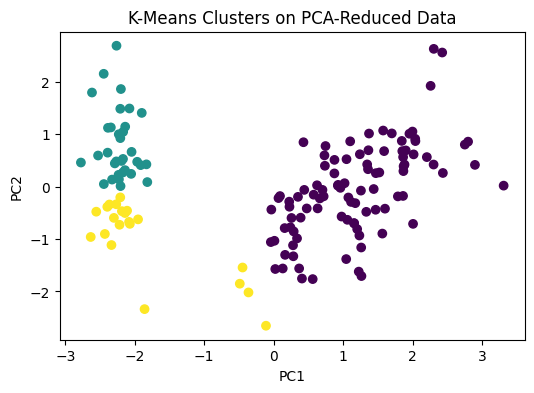

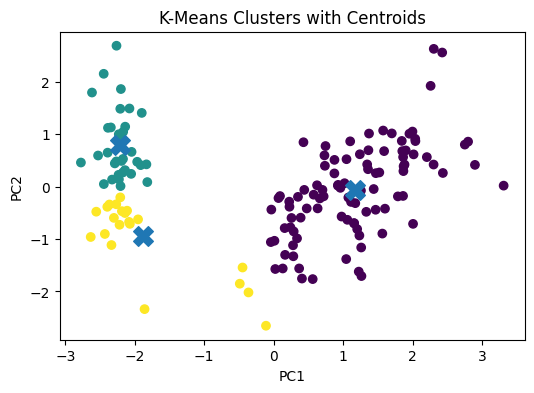

In [14]:
### Step 1: Import K-Means

from sklearn.cluster import KMeans

### Step 2: Fit K-Means on the standardized data

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

'''
In this example:

n_clusters=3 means we want the algorithm to form 3 clusters
labels stores the cluster assignment for each data point
centroids stores the center of each cluster

'''

### Visualizing K-Means Clusters on PCA Output

### Since PCA reduced the dataset to 2 dimensions, we can now visualize the clusters easily.

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA-Reduced Data")
plt.show()

# This plot helps us see how the algorithm grouped the data points after dimensionality reduction.

# Visualizing Cluster Centroids

'''
To make the plot more informative, we can also show the centroids.

Since the centroids were computed in the original standardized feature space, we first project them into the same PCA space.
'''
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters with Centroids")
plt.show()

